# Bike Availability Modeling



# Part 1 Feature pairs check

### Feature Engineering Notes
- To ensure consistency between training and deployment, feature names in extraction are kept exactly the same as model input names.
- This allows the Flask prediction pipeline to consume Weather API and Bike database fields directly, without extra mapping or transformation.
- Since bike availability is strongly related to weather and historical demand, two history-based features are introduced:
  - `bikes_1d_mean`: mean available bikes over the previous 1-day window, mainly for short-horizon forecasts (within 1 day).
  - `bikes_same_slot_mean`: historical mean for the same time slot, mainly for medium-horizon forecasts (2-7 days).
- Together, these features capture both short-term fluctuations and recurring time-slot patterns.


/var/folders/jw/0ttqd5gn6_zf0xv62ypjvn9r0000gn/T/ipykernel_91674/2720327680.py:39: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_rolling_1d_mean)


Shape after filter: (298946, 25)
Top 20 by |correlation|:
bikes_1d_mean           0.771299
bikes_same_slot_mean    0.596810
capacity                0.205051
lon                     0.124585
humidity                0.011577
day                     0.003829
weekend                 0.003756
temp                    0.002011
minute                 -0.000847
weekday                -0.000935
number                 -0.001356
pressure               -0.002130
hour                   -0.004754
lat                    -0.137569
num_docks_available    -0.717459
stno                         NaN
year                         NaN
month                        NaN
Name: num_bikes_available, dtype: float64


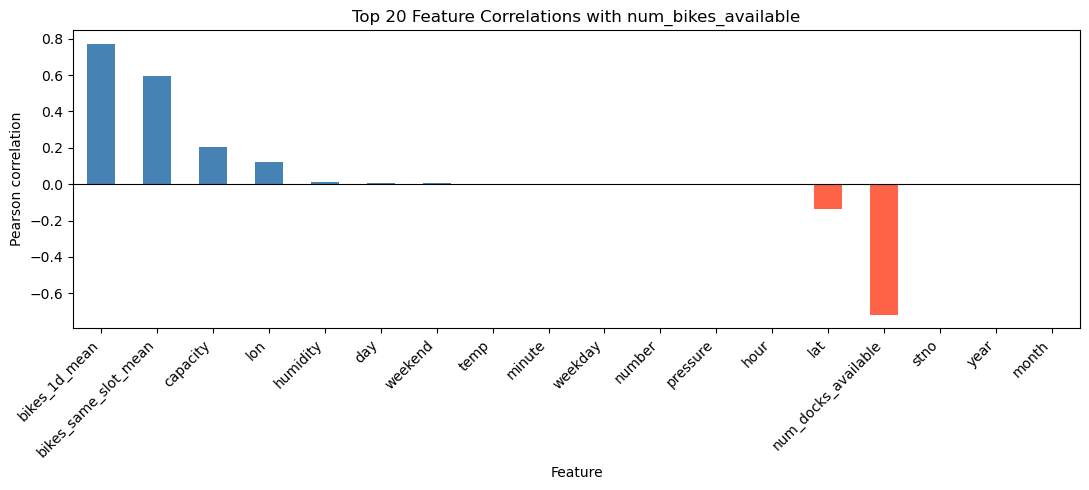

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt

ROLLING_WINDOW = '1D'  # dynamic time window: previous 1 day rolling window is to avoid missing data affact the prediction, and it naturally adapts to varying data frequency and gaps

df_raw = pd.read_csv('final_merged_data.csv.gz', compression='gzip')
if 'number' not in df_raw.columns and 'station_id' in df_raw.columns:
    df_raw = df_raw.rename(columns={'station_id': 'number'})

# Weather / time features
df_raw['temp'] = (pd.to_numeric(df_raw['max_air_temperature_celsius']) + pd.to_numeric(df_raw['min_air_temperature_celsius'])) / 2
df_raw['pressure'] = (pd.to_numeric(df_raw['max_barometric_pressure_hpa']) + pd.to_numeric(df_raw['min_barometric_pressure_hpa'])) / 2
hum_avg = (pd.to_numeric(df_raw['max_relative_humidity_percent']) + pd.to_numeric(df_raw['min_relative_humidity_percent'])) / 2
df_raw['humidity'] = (hum_avg > 90).astype(int)
df_raw['weekday'] = pd.to_numeric(df_raw['day']) % 7
df_raw['weekend'] = df_raw['weekday'].isin([5, 6]).astype(int)

# lag features (to prevent data leakage)
df_raw['last_reported'] = pd.to_datetime(df_raw['last_reported'])
df_raw['number'] = pd.to_numeric(df_raw['number'])
df_raw['num_bikes_available'] = pd.to_numeric(df_raw['num_bikes_available'])

lag_base = df_raw.dropna(subset=['last_reported', 'number', 'num_bikes_available']).copy()
lag_base['_orig_idx'] = lag_base.index
lag_base['number'] = lag_base['number'].astype(int)
lag_base = lag_base.sort_values(['number', 'last_reported']).reset_index(drop=True)

# bikes_1d_mean: mean of available records in the previous 1 day (NaN skipped)
def _rolling_1d_mean(group):
    g2 = group.sort_values('last_reported').copy()
    shifted = g2['num_bikes_available'].shift(1)
    # time-based rolling avoids fixed record counts and naturally adapts to data gaps
    ts = pd.DataFrame({'last_reported': g2['last_reported'], 'v': shifted}).set_index('last_reported')
    g2['bikes_1d_mean'] = ts['v'].rolling(ROLLING_WINDOW, min_periods=1).mean().to_numpy()
    return g2

lag_base = (
    lag_base.groupby('number', group_keys=False)
            .apply(_rolling_1d_mean)
            .reset_index(drop=True)
)
# lag feature considering hour/minute: compute historical average for the same time slot
slot_hour = lag_base['last_reported'].dt.hour
slot_minute = lag_base['last_reported'].dt.minute
lag_base['bikes_same_slot_mean'] = (
    lag_base.groupby(['number', slot_hour, slot_minute])['num_bikes_available']
            .transform(lambda s: s.shift(1).expanding(min_periods=3).mean())
)

station_mean = lag_base.groupby('number')['num_bikes_available'].transform('mean')
global_mean = float(lag_base['num_bikes_available'].mean())
for c in ['bikes_1d_mean', 'bikes_same_slot_mean']:
    lag_base[c] = lag_base[c].fillna(station_mean).fillna(global_mean)

df_raw.loc[lag_base['_orig_idx'], 'bikes_1d_mean'] = lag_base['bikes_1d_mean'].values
df_raw.loc[lag_base['_orig_idx'], 'bikes_same_slot_mean'] = lag_base['bikes_same_slot_mean'].values

# Drop redundant raw weather columns
weather_keywords = ['temperature', 'humidity', 'pressure', 'barometric', 'weather', 'wind', 'rain', 'snow', 'soil', 'earth', 'grass', 'quality_indicator']
keep_weather = {'temp', 'pressure', 'humidity'}
drop_cols = [c for c in df_raw.columns if any(k in c.lower() for k in weather_keywords) and c not in keep_weather]
df_model = df_raw.drop(columns=drop_cols, errors='ignore').copy()

# Top 20 correlations
num_cols = df_model.select_dtypes(include=['number']).columns.tolist()
corr = (
    df_model[[c for c in num_cols if c != 'num_bikes_available'] + ['num_bikes_available']]
    .corr(numeric_only=True)['num_bikes_available']
    .drop('num_bikes_available')
)
plot_data = corr.loc[corr.abs().sort_values(ascending=False).head(20).index].sort_values(ascending=False)

print(f'Shape after filter: {df_model.shape}')
print('Top 20 by |correlation|:')
print(plot_data)

plt.figure(figsize=(11, 5))
colors = ['steelblue' if v >= 0 else 'tomato' for v in plot_data.values]
plot_data.plot(kind='bar', color=colors)
plt.title('Top 20 Feature Correlations with num_bikes_available')
plt.xlabel('Feature')
plt.ylabel('Pearson correlation')
plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# Part 1 Conclusion

Based on the correlation analysis and deployment constraints, the final feature set was selected to maximise predictive relevance while maintaining end-to-end consistency between training and inference.

The retained features are as follows:
- Temporal features: `day`, `hour`, `minute`
- Weather features: `temp`, `pressure`, `humidity`
- Spatial/station features: `lon`, `lat`, `number`, `capacity`
- Historical bike-demand features: `bikes_1d_mean`, `bikes_same_slot_mean`

From a methodological perspective, feature naming was deliberately aligned with model input fields so that the Flask prediction pipeline can consume Weather API and Bike database outputs directly, without additional field transformation.

To better represent demand dynamics across forecasting horizons, two history-based variables were introduced: `bikes_1d_mean` captures short-term local behaviour (within 1 day), while `bikes_same_slot_mean` captures recurring slot-level patterns for medium-range forecasting (2-7 days).

Finally, `num_docks_available` was excluded to reduce redundancy and mitigate potential leakage, as it is structurally complementary to `num_bikes_available`.


## Part 2: Data Cleaning
Load raw data, build time/weather/lag features, and produce `df_clean`.


In [14]:
import pandas as pd

# Part 2: Data Cleaning（reuse features from Part 1）
df = df_model.copy()

# Align with training fields
df['available_bikes'] = df['num_bikes_available']
df['lng'] = df['lon']

features = [
    'number', 'capacity', 'day', 'hour', 'minute',
    'temp', 'pressure', 'humidity',
    'lng', 'lat',
    'bikes_1d_mean',
    'bikes_same_slot_mean',
]
target = 'available_bikes'

df_clean = (
    df[features + [target, 'last_reported']]
    .dropna()
    .sort_values('last_reported')
    .reset_index(drop=True)
)
df_clean[features + [target]].to_csv('data_cleaned.csv', index=False)

print(f'Cleaned shape: {df_clean.shape}')
print('Saved: data_cleaned.csv')
display(df_clean.head(3))


Cleaned shape: (298946, 14)
Saved: data_cleaned.csv


,number,capacity,day,hour,minute,temp,pressure,humidity,lng,lat,bikes_1d_mean,bikes_same_slot_mean,available_bikes,last_reported
0,10,16,1,0,10,13.955,1002.41,0,-6.266802,53.344006,12.669023,12.669023,15,2024-12-01 00:10:00
1,53,40,1,0,10,13.955,1002.41,0,-6.260590,53.337130,13.695784,13.695784,7,2024-12-01 00:10:00
2,54,33,1,0,10,13.955,1002.41,0,-6.262980,53.336020,13.502787,13.502787,12,2024-12-01 00:10:00


# Part 3: Model Training
Train linear regression using `df_clean`:
- Use one-hot encoding for `number`
- Use time-ordered 70/30 split

## 3.1. Baseline Model: Linear Regression with Lag Features time disorder

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
from pathlib import Path

X = df_clean[features]
y = df_clean[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
# time slot disorder as baseline result.
models = {
    'Linear Regression': LinearRegression(),
}

results = []

for name, model in models.items():
    print(f"Model training {name}...")

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({
        'model': name,
        'MAE': round(mae, 4),
        'RMSE': round(rmse, 4),
        'R²': round(r2, 4),
    })

results_df = pd.DataFrame(results).set_index('model')
display(results_df)

# Save the model
model_dir = Path('machine_learning') if Path('machine_learning').exists() else Path('.')
model_dir.mkdir(parents=True, exist_ok=True)

model_path = model_dir / 'linear_regression_lag_model.joblib'
meta_path = model_dir / 'linear_regression_lag_model_meta.joblib'

joblib.dump(model, model_path)
joblib.dump({'features': features, 'target': target}, meta_path)

print(f'Saved model: {model_path}')
print(f'Saved meta : {meta_path}')


Model training Linear Regression...


,MAE,RMSE,R²
model,,,
Linear Regression,4.3723,5.9366,0.6305


Saved model: linear_regression_lag_model.joblib
Saved meta : linear_regression_lag_model_meta.joblib


# Part 4: Analyse model performance
- 1.Linear Regression
- 2.SVR
- 3.Random Forest 
- 4.Ridge Regression
- 5.Decision Tree

A standard random train-test split was initially used to establish a baseline model.
However, for time-series data this can cause data leakage if future observations are included in training.
To avoid this, we use a chronological 70/30 split: the first 70% for training and the last 30% for testing.


In [16]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.svm import LinearSVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

X = df_clean[features]
y = df_clean[target]

# One-hot encode station id
X = pd.get_dummies(X, columns=['number'], drop_first=True)

# Time-based split (70/30, no CV)
split_idx = int(len(X) * 0.7)

X_train = X.iloc[:split_idx]  # past
X_test = X.iloc[split_idx:]   # future

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(max_depth=10),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        n_jobs=-1,
        random_state=42
    ),
    "SVR (Linear)": LinearSVR(max_iter=5000)
}


In [17]:
results = []

trained_models = {}

for name, model in models.items():
    print(f"\nTraining {name}...")

    # Scale ONLY for SVR
    if "SVR" in name:
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    trained_models[name] = model

    # Test metrics (70/30 split only)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Test MAE": round(mae, 4),
        "Test RMSE": round(rmse, 4),
        "Test R²": round(r2, 4)
    })

results_df = pd.DataFrame(results).sort_values(by="Test R²", ascending=False)
display(results_df)



Training Linear Regression...

Training Ridge Regression...

Training Decision Tree...

Training Random Forest...

Training SVR (Linear)...


,Model,Test MAE,Test RMSE,Test R²
4,SVR (Linear),3.2291,4.5439,0.7455
0,Linear Regression,3.3921,4.6280,0.7360
1,Ridge Regression,3.3917,4.6280,0.7360
3,Random Forest,3.4531,4.7453,0.7225
2,Decision Tree,3.7806,5.2955,0.6544


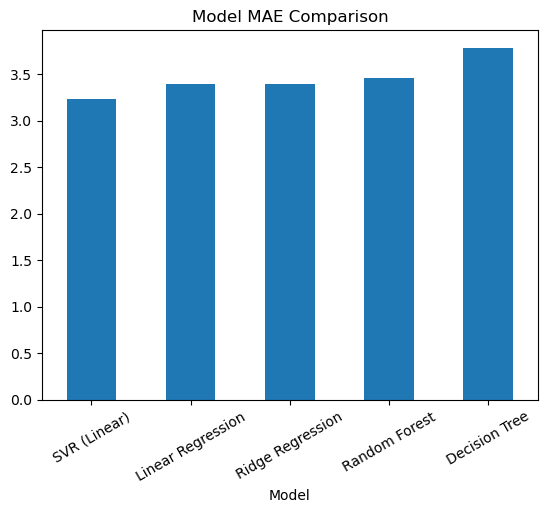

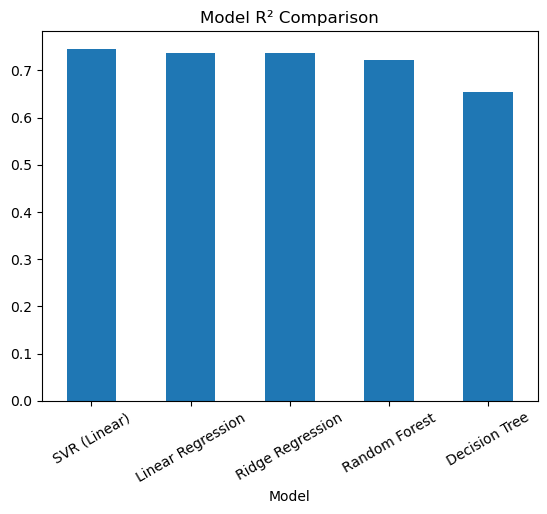

Saved: decision_tree_model.joblib
Saved: decision_tree_model.pkl
Saved: linear_regression_lag_model.joblib
Saved: linear_regression_lag_model.pkl
Saved: random_forest_model.joblib
Saved: random_forest_model.pkl
Saved: ridge_regression_model.joblib
Saved: ridge_regression_model.pkl
Saved: svr_model.joblib
Saved: svr_model.pkl
Saved: linear_regression_lag_model_meta.joblib


In [18]:
import matplotlib.pyplot as plt
import pickle
import joblib
from pathlib import Path

# MAE comparison
results_df.set_index('Model')['Test MAE'].plot(kind='bar', title='Model MAE Comparison')
plt.xticks(rotation=30)
plt.show()

# R² comparison
results_df.set_index('Model')['Test R²'].plot(kind='bar', title='Model R² Comparison')
plt.xticks(rotation=30)
plt.show()

# Save trained models (filenames aligned with existing naming)
model_dir = Path('machine_learning') if Path('machine_learning').exists() else Path('.')
model_dir.mkdir(parents=True, exist_ok=True)

file_map = {
    'Decision Tree': 'decision_tree_model',
    'Linear Regression': 'linear_regression_lag_model',
    'Random Forest': 'random_forest_model',
    'Ridge Regression': 'ridge_regression_model',
    'SVR (Linear)': 'svr_model',
}

for model_name, base_name in file_map.items():
    fitted_model = trained_models[model_name]

    joblib_path = model_dir / f'{base_name}.joblib'
    pkl_path = model_dir / f'{base_name}.pkl'

    joblib.dump(fitted_model, joblib_path)
    with open(pkl_path, 'wb') as f:
        pickle.dump(fitted_model, f)

    print(f'Saved: {joblib_path}')
    print(f'Saved: {pkl_path}')

meta_path = model_dir / 'linear_regression_lag_model_meta.joblib'
joblib.dump({'features': features, 'target': target}, meta_path)
print(f'Saved: {meta_path}')


## Model Comparison and Analysis

### Overall Performance

Among the evaluated models, **Support Vector Regression (SVR)** achieved the lowest test Mean Absolute Error (MAE), indicating strong predictive accuracy in terms of absolute error. Linear Regression and Ridge Regression performed similarly, with competitive MAE and R² scores. Random Forest and Decision Tree performed worse, with higher MAE and lower R² values on the holdout set.

### Linear vs Ridge Regression

Linear Regression and Ridge Regression produced nearly identical results. This suggests that **regularisation had minimal impact**, likely because the feature set is relatively small and does not suffer heavily from multicollinearity.

### SVR Performance

SVR (Linear) slightly outperformed both linear models in terms of MAE, suggesting it captures subtle patterns not fully modelled by ordinary least squares.

### Tree-Based Models

Random Forest and Decision Tree performed worse than the linear-family models on the 70/30 holdout evaluation. This may indicate that the current feature set is not rich enough for tree-based models to show their full advantage.

### Key Takeaways

* **Best MAE (accuracy):** SVR
* **Best R² (explained variance):** Linear Regression / Ridge Regression
* **Worst performer:** Decision Tree

### Conclusion

Using a chronological 70/30 split, linear-family models remain strong and consistent baselines. SVR yields the lowest error, while Linear/Ridge provide a good balance between simplicity and predictive performance.


# Part 5 :Prediction applied on Flask API
### modification on APP.py to load the model and make prediction
## Final Note: Why We Use RR Instead of LR

In real Flask API inference, Linear Regression (LR) showed clear numerical instability: `raw_pred` repeatedly exploded to extremely large positive or negative values (for example, `+3.2e5` and `-7.5e5`). Those outputs were then clipped by post-processing to boundary values (such as `0` or `capacity`), which made the UI appear as if predictions were frequently stuck at extremes and inconsistent with real station status.
- 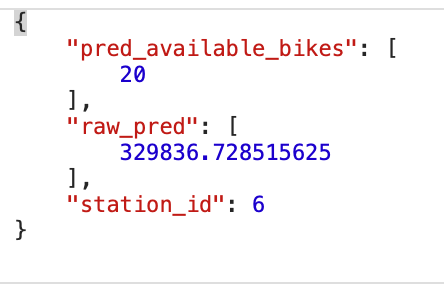

- 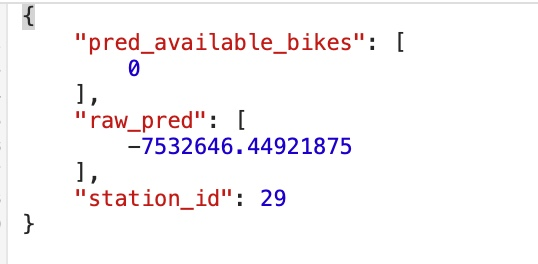
- The main reason is the current high-dimensional feature space with strong multicollinearity. Station one-hot features (`number_*`) are used together with continuous location/capacity features (`lat`, `lng`, `capacity`) plus time, weather, and historical statistics. Under ordinary least squares (OLS), this can lead to ill-conditioned estimation, highly sensitive coefficients, and prediction explosion during serving.

Therefore, we selected Ridge Regression (RR). RR introduces L2 regularization to constrain coefficient magnitude, improve numerical conditioning, and reduce extreme prediction risk under the same feature design. In practice, RR provides more stable and robust online inference than LR for this project.
